In [1]:
"""



"""

import os
import sys
import getpass

# Add the overmind dir here.

nb_dir = os.getcwd()
# add it (and/or its parent) to sys.path
sys.path.insert(0, nb_dir)
sys.path.insert(0, os.path.abspath(os.path.join(nb_dir, os.pardir)))


#sys.path.append("/home/david/tradefi/pkt_2/overmind")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print("Hello World")

Hello World


In [3]:
import importlib

from strat_main.tools import histreturns
from strat_main.util.chron import dates_list, t_to_secs

#from strat_main.templatizers.SigFormer import *
#from strat_main.util import viz
#from strat_main.util import signaloptimizer

importlib.reload(histreturns)


<module 'strat_main.tools.histreturns' from '/home/pktrade/tradefi/retraded/overmind/strat_main/tools/histreturns.py'>

In [4]:

# Let's


start_d = "20250901"
# Not inclusive.
end_d = "20250922"
dates = dates_list(start_d, end_d)

tmp_dir = os.path.join("/home/{}/scratch/histreturns/".format(getpass.getuser()))
syms_to_market = {"ES" : "CME", "NQ": "CME", "BTC" : "Hyperliquid", "ETH": "Hyperliquid", "SOL": "Hyperliquid", "SPY": "USEQ", "QQQ": "USEQ"}






In [ ]:
print()

In [5]:
# Download histdata for symbols...
hr = histreturns.HistReturns(syms_to_market, tmp_dir, start_d, end_d)


In [6]:
x = hr.get_returns_crypto("BTC")


Crypto: checking for histdata
Getting Hyperliquid/BTC_l2Book_20250919.gzpbf from aws (8 total). Proceed? [y/n]


In [7]:
print("All done")

All done


In [8]:
x = hr.get_returns_cme("ES")
x = hr.get_returns_cme("NQ")

x = hr.get_returns_crypto("BTC")
x = hr.get_returns_crypto("ETH")

x = hr.get_returns_useq("SPY")
x = hr.get_returns_useq("QQQ")


Getting histdata from databento
Getting histdata from databento
/home/pktrade/scratch/histreturns/cache/BTC_20250901_20250922_returns.csv already exists
Crypto: checking for histdata
Getting Hyperliquid/ETH_l2Book_20250919.gzpbf from aws (8 total). Proceed? [y/n]
Getting histdata from databento


/home/pktrade/tradefi/retraded/overmind/strat_main/tools/histreturns.py:152: BentoWarning: The streaming request contained one or more days which have reduced quality: 2025-09-03 (degraded), 2025-09-08 (degraded), 2025-09-12 (degraded). See: https://databento.com/docs/api-reference-historical/metadata/metadata-get-dataset-condition
  px_data = client.timeseries.get_range(


Getting histdata from databento


/home/pktrade/tradefi/retraded/overmind/strat_main/tools/histreturns.py:152: BentoWarning: The streaming request contained one or more days which have reduced quality: 2025-09-03 (degraded), 2025-09-08 (degraded), 2025-09-12 (degraded). See: https://databento.com/docs/api-reference-historical/metadata/metadata-get-dataset-condition
  px_data = client.timeseries.get_range(


In [ ]:
start_d = "20250901"
# Not inclusive.
end_d = "20250922"


Mornings 1

Removed Outlier Rows (abs > 0.10 in either column):
 Empty DataFrame
Columns: [t_1, ret_1, t_2, ret_2]
Index: []


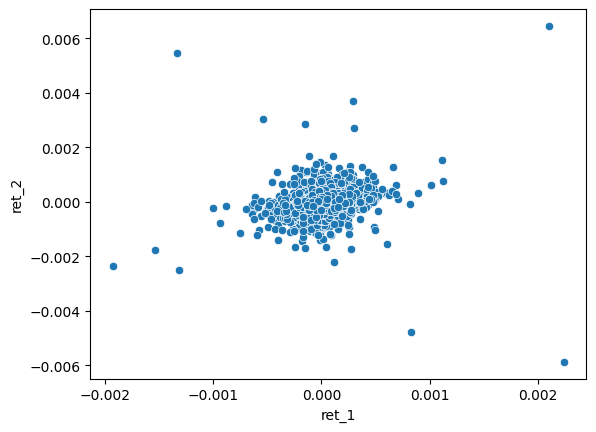

Coefficient (β): 0.4548
R²:              0.03558
US 1

Removed Outlier Rows (abs > 0.10 in either column):
 Empty DataFrame
Columns: [t_1, ret_1, t_2, ret_2]
Index: []


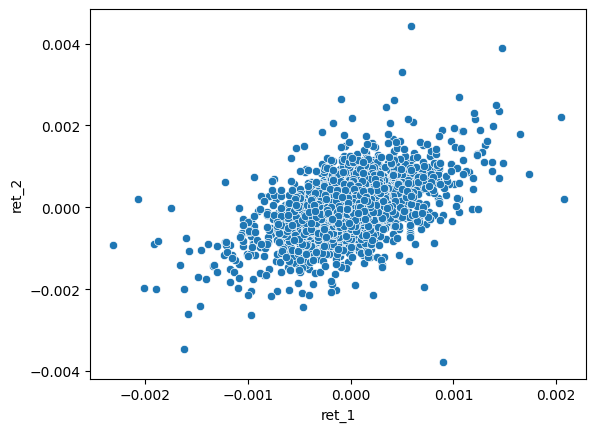

Coefficient (β): 0.7982
R²:              0.2373
Night 1 

Removed Outlier Rows (abs > 0.10 in either column):
 Empty DataFrame
Columns: [t_1, ret_1, t_2, ret_2]
Index: []


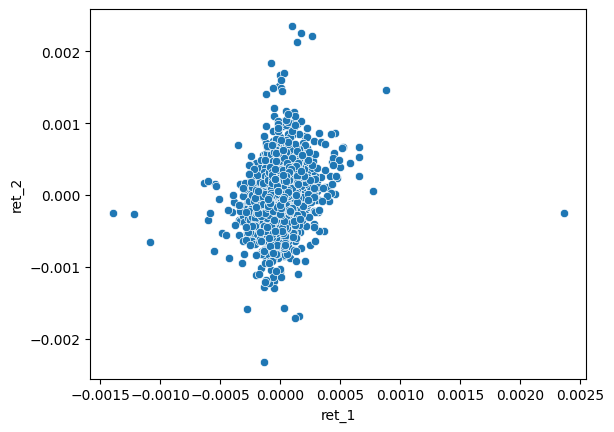

Coefficient (β): 0.5615
R²:              0.04444


In [23]:
# OK. Let's check on them now.
importlib.reload(histreturns)
# Let's try to do the regression now?

start_d = "20250901"
end_d = "20250922"
morning_start = "04:00:00"
morning_end = "09:00:00"

day_start = "09:30:00"
day_end = "15:50:00"

night_start = "16:10:00"
night_end = "22:00:00"

# Before libration
print("Mornings 1")
histreturns.regress_syms(hr, "NQ", "BTC", start_d, end_d, morning_start, morning_end, plot=True)
print("US 1")
histreturns.regress_syms(hr, "NQ", "BTC", start_d, end_d, day_start, day_end, plot=True)
print("Night 1 ")
histreturns.regress_syms(hr, "NQ", "BTC", start_d, end_d, night_start, night_end, plot=True)




US 1

Removed Outlier Rows (abs > 0.10 in either column):
             t_1     ret_1         t_2     ret_2
893  1757079119  0.000828  1757079117  0.998829


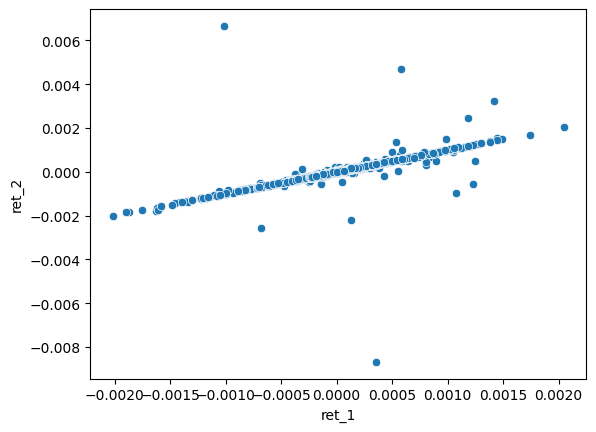

Coefficient (β): 0.9737
R²:              0.6945


In [21]:
# OK. Let's check on them now.
importlib.reload(histreturns)
# Let's try to do the regression now?

start_d = "20250901"
end_d = "20250922"

day_start = "09:30:00"
day_end = "15:50:00"

# Before libration
print("US 1")
histreturns.regress_syms(hr, "NQ", "QQQ", start_d, end_d, day_start, day_end, plot=True)



In [60]:
# Let's just calculate some historical CME things
import databento as db


def my_hist_cme(my_sym):
    # Establish connection and authenticate
    client = db.Historical(histreturns.DB_API_KEY
)

    # Did the symbology need to be right? Ugh.

    data = client.timeseries.get_range(
        dataset="GLBX.MDP3",
        symbols=[my_sym],
        stype_in="continuous",
        schema="bbo-1m",
        start="2024-12-06T21:00:00",
        end="2024-12-08T23:00:00",
        limit=1000,
    )

    df = data.to_df()

    df2 = df[['ts_event', 'bid_px_00', 'ask_px_00']].copy()

    # 2. make sure ts_event is a datetime (with UTC)
    #df2['ts_event'] = pd.to_datetime(df2['ts_event'], utc=True)
    df2['ts_event'] = pd.to_datetime(df2['ts_event'], utc=True).dt.tz_convert('America/New_York')

    # 3. add seconds‐since‐epoch
    #    (pandas stores datetimes as nanoseconds since epoch internally)

    # 4. add mid‐price
    df2['mid_px'] = (df2['bid_px_00'] + df2['ask_px_00']) / 2
    df2 = df2.iloc[1:].reset_index(drop=True)
    pd.set_option('display.max_rows', None)

    print(df2)
    pd.reset_option('display.max_rows')
